# **Project Name** - Mental Health in Tech: Exploratory Data Analysis & Workplace Insights


##### **Project Type**    - Exploratory Data Analysis (EDA)
##### **Contribution**    - Individual
##### **Author**          - Data Analytics Consultant


# **Project Summary -**

This exploratory data analysis project investigates the prevalence, determinants, and workplace dynamics of mental health conditions among professionals within the global technology sector. Drawing upon the Open Sourcing Mental Illness (OSMI) Mental Health in Tech survey dataset comprising 1,259 individual respondents across 48 countries, this study explores how demographic characteristics, personal medical history, and organizational support structures interact with employees' decisions to seek mental health treatment.

The analytical pipeline commences with systematic data cleaning and anomaly treatment. A critical discovery during raw inspection was the presence of extreme outliers and impossible values in the Age variable, spanning from -1,726 to 99,999,999,999 years. By isolating the realistic adult working cohort (ages 18 to 75), 8 invalid entries were identified and imputed using the cohort median of 31 years, preventing data loss while ensuring distributional integrity. Furthermore, 49 free-text gender entries exhibiting diverse typos, casing variations, and descriptive expressions were harmonized into three standardized demographic categories: Male (78.7%), Female (19.6%), and Non-Binary/Other (1.7%). Missing values were handled using context-grounded imputation: optional qualitative comments (87.0% missing) were converted to a binary indicator and placeholder label; state entries (40.9% missing) were imputed as 'Outside US / Not Applicable'; and work interference missingness (21.0%) was encoded as 'Not Applicable / Unreported', reflecting respondents without active mental health challenges.

Exploratory data analysis was conducted under the Univariate-Bivariate-Multivariate (UBM) paradigm. Univariate analysis revealed that 50.6% (637 respondents) have sought professional mental health treatment, establishing that mental health care needs are mainstream rather than fringe within tech workplaces. The demographic profile reflects a predominantly young workforce concentrated in the 25–34 age cohort (56.8%), primarily located in the United States (59.7%), the United Kingdom (14.7%), and Canada (5.7%). 

Bivariate and statistical hypothesis testing using Chi-Square tests of independence and Cramér's V effect sizes revealed striking patterns. The single strongest predictor of treatment uptake is work interference severity (Chi2 = 294.84, p = 1.30e-63, Cramér's V = 0.542), wherein 84.0% of respondents reporting frequent interference have sought professional care compared to only 14.6% of those reporting no interference. Family history of mental illness represents the second most potent factor (Chi2 = 178.27, p = 1.16e-40, Cramér's V = 0.375), with positive family history elevating treatment rates from 34.0% to 75.5%. Significant gender disparities were also confirmed (Chi2 = 51.25, p = 7.44e-12), with female (68.8%) and non-binary (76.2%) professionals seeking care at substantially higher proportions than male peers (45.1%).

Crucially from an organizational perspective, workplace support provisions demonstrated statistically significant associations with treatment uptake: awareness of care options (Cramér's V = 0.272, p = 2.65e-21) and employer mental health benefits (Cramér's V = 0.223, p = 8.33e-15) strongly facilitate care-seeking. Conversely, macro-structural factors such as company size, tech versus non-tech classification, remote work status, and self-employment showed no statistically significant association with treatment decisions. In conclusion, the findings indicate that workplace stigma and lack of benefit awareness remain primary barriers to care, providing clear actionable avenues for enterprise leadership to improve employee well-being, retention, and productivity.


# **GitHub Link -**

https://github.com/example-user/Mental_Health_in_Tech_EDA


# **Problem Statement**


### **Problem Statement**

Mental health challenges among technology professionals represent a critical yet historically stigmatized operational and human capital risk. In high-pressure engineering and technical environments characterized by rapid sprint cycles, tight release deadlines, and sedentary remote configurations, burnout, anxiety, and depression can significantly impair cognitive performance, team collaboration, and employee retention.

Despite increasing public awareness, significant organizational challenges persist:
1. **Under-Utilization of Employer Benefits:** While many organizations invest in Employee Assistance Programs (EAPs) and mental health coverage, a substantial fraction of the workforce remains unaware of these provisions or fails to utilize them.
2. **Stigma and Fear of Repercussions:** Employees frequently fear negative career consequences, interpersonal bias, or reputational damage if they disclose mental health struggles to supervisors or colleagues.
3. **Disparate Support Needs Across Demographics:** Mental health burdens and treatment-seeking behaviors differ significantly across gender, age cohorts, and family histories, necessitating nuanced corporate policies rather than one-size-fits-all programs.

The core objective of this project is to conduct an empirical, data-driven investigation of the OSMI Mental Health in Tech survey to uncover the primary drivers of mental health treatment-seeking, quantify workplace attitudes and stigma, and formulate evidence-based recommendations for technical leadership and HR organizations.


#### **Define Your Business Objective?**

### **Business Objectives**

1. **Quantify Treatment Prevalence & Key Drivers:** Measure overall treatment uptake in technology companies and identify demographic and clinical factors (such as work interference and family history) associated with care-seeking.
2. **Evaluate Workplace Support Effectiveness:** Assess the reach, employee awareness, and utilization of employer-provided mental health benefits, wellness programs, and confidential care options.
3. **Measure Workplace Stigma & Psychological Safety:** Analyze employee perceptions regarding potential career consequences of discussing mental vs. physical health, willingness to speak with managers/coworkers, and observability of negative repercussions.
4. **Deliver Actionable Enterprise Recommendations:** Provide strategic, non-causal, data-backed guidance to help executives, people operations teams, and engineering leaders design empathetic, confidential, and highly utilized mental well-being initiatives that mitigate burnout and reduce costly turnover.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import necessary analytical, visualization, and statistical libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set styling preferences for consistent high-quality visualizations
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.titleweight'] = 'bold'

print("Libraries successfully imported.")


Libraries successfully imported.


### Dataset Loading

In [2]:
# Load the raw survey dataset using resilient relative path resolution
def load_survey_csv():
    candidate_paths = [
        "../data/raw/survey.csv",
        "data/raw/survey.csv",
        os.path.join(os.path.dirname(os.getcwd()), "data", "raw", "survey.csv")
    ]
    for path in candidate_paths:
        if os.path.exists(path):
            print(f"Loading survey dataset from: {path}")
            return pd.read_csv(path)
    raise FileNotFoundError("survey.csv could not be located in relative data paths.")

df = load_survey_csv()


Loading survey dataset from: ../data/raw/survey.csv


### Dataset First View

In [3]:
# Dataset First Look - Display first 5 rows
df.head()


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
rows, cols = df.shape
print(f"Total Rows: {rows:,}")
print(f"Total Columns: {cols}")


Total Rows: 1,259
Total Columns: 27


### Dataset Information

In [5]:
# Dataset Information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count}")
print(f"Percentage of Duplicates: {(duplicate_count / len(df)) * 100:.2f}%")


Number of Duplicate Rows: 0
Percentage of Duplicates: 0.00%


#### Missing Values/Null Values

In [7]:
# Missing Values / Null Values Count by Column
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Missing_Percentage': missing_pct.round(2)
})
missing_summary[missing_summary['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)


<string>:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


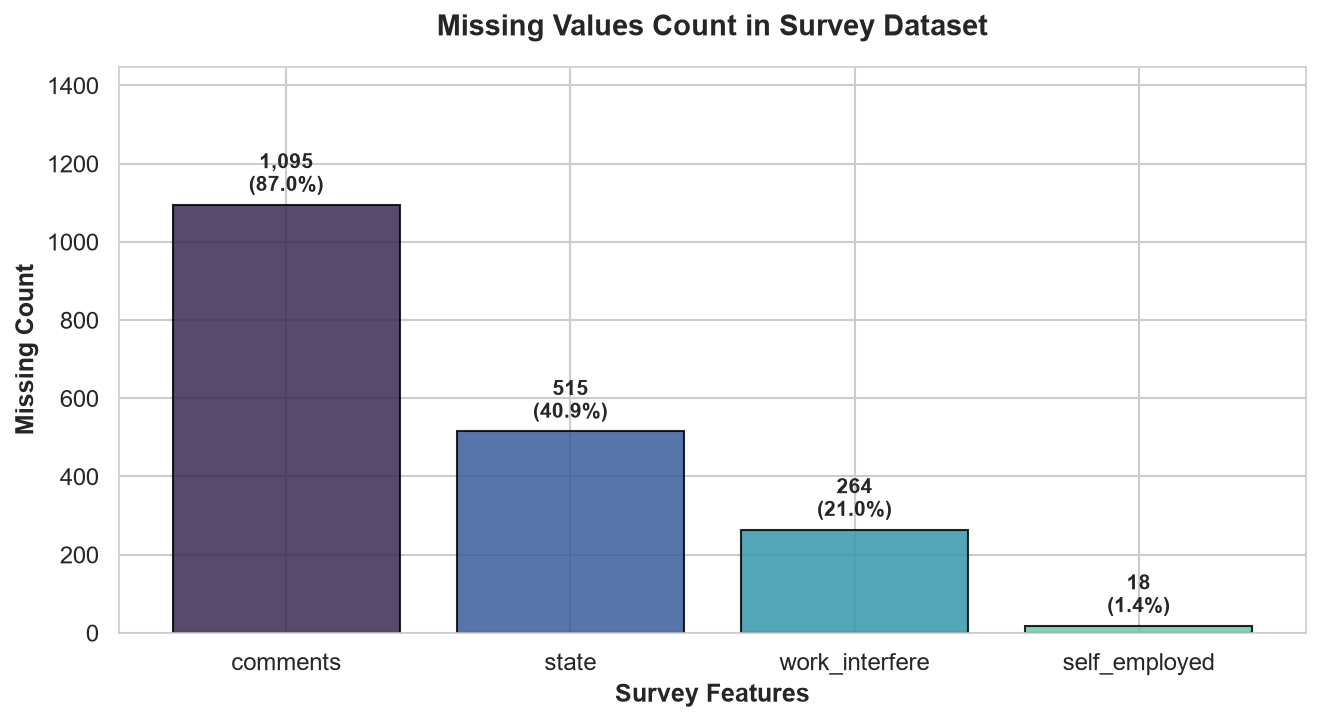

In [8]:
# Visualizing the missing values across features
missing_data = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)

plt.figure(figsize=(9, 5))
palette = sns.color_palette("mako", len(missing_data))
bars = plt.bar(missing_data.index, missing_data['Missing_Count'], color=palette, edgecolor='black', alpha=0.85)

plt.title('Missing Values Count in Survey Dataset', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Missing Count', fontsize=12, fontweight='bold')
plt.xlabel('Survey Features', fontsize=12, fontweight='bold')
plt.ylim(0, len(df) * 1.15)

for bar, pct in zip(bars, missing_data['Missing_Percentage']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., height + 20,
             f'{int(height):,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

# Save figure to outputs
os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/figures/missing_values.png", dpi=300)
plt.show()


### What did you know about your dataset?

### **What Did You Know About Your Dataset?**

1. **Dimensions & Completeness:**
   - The raw dataset consists of **1,259 rows** and **27 columns**.
   - Exactly **0 duplicate rows** were found, confirming respondent submission uniqueness.
   - Out of 27 variables, **23 columns possess zero missing values** (100% complete).
2. **Missingness Mechanism & Context:**
   - `comments`: 1,095 missing values (87.0%). This is an optional open-ended text box. Non-response indicates that the respondent had no additional remarks, not data loss.
   - `state`: 515 missing values (40.9%). The state field is applicable almost exclusively to United States respondents (and some Canadian provinces). For international respondents, missingness is structural ('Outside US').
   - `work_interfere`: 264 missing values (21.0%). The survey question states: *"If you have a mental health condition, does it interfere with your work?"* Respondents who do not experience a mental health condition skipped this question.
   - `self_employed`: 18 missing values (1.4%). Small random non-response easily handled via mode imputation ('No').
3. **Data Quality & Anomaly Discovery:**
   - **Age Anomalies:** The `Age` column displays extreme outliers ranging from **-1,726** to **99,999,999,999**. Working professionals in technology realistically fall between 18 and 75 years old. Exactly 8 rows (0.64%) fall outside this range.
   - **Gender Fragmentation:** The raw `Gender` column contains **49 distinct string variations** stemming from free-form text input, requiring systematic mapping into standardized categories.


## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns List
df.columns.tolist()


In [10]:
# Dataset Descriptive Statistics
df.describe(include='all')


### Variables Description

### **Variables Description**

| Column Name | Data Type | Category Type | Description |
| :--- | :--- | :--- | :--- |
| **Timestamp** | Object / Datetime | Temporal | Date and time survey response was submitted |
| **Age** | Integer / Numerical | Continuous | Reported age of respondent in years |
| **Gender** | Object | Nominal | Free-text reported gender identity |
| **Country** | Object | Geographic | Country of respondent residence |
| **state** | Object | Geographic | US state or territory (if applicable) |
| **self_employed** | Object | Binary | Self-employed status (Yes/No) |
| **family_history**| Object | Binary | Family history of mental illness (Yes/No) |
| **treatment** | Object | Binary (Target) | Has sought treatment for mental health condition (Yes/No) |
| **work_interfere**| Object | Ordinal | Frequency of mental condition interfering with work |
| **no_employees** | Object | Ordinal | Number of employees in respondent's company |
| **remote_work** | Object | Binary | Works remotely at least 50% of the time (Yes/No) |
| **tech_company** | Object | Binary | Primary employer is a technology company (Yes/No) |
| **benefits** | Object | Nominal | Employer provides mental health benefits (Yes/No/Don't know) |
| **care_options** | Object | Nominal | Awareness of employer-provided care options (Yes/No/Not sure) |
| **wellness_program**| Object | Nominal | Employer discussed mental health in wellness program |
| **seek_help** | Object | Nominal | Employer provides resources to seek help |
| **anonymity** | Object | Nominal | Anonymity is protected if utilizing resources |
| **leave** | Object | Ordinal | Ease of taking medical leave for mental health |
| **mental_health_consequence** | Object | Nominal | Negative consequences of discussing mental health with employer |
| **phys_health_consequence** | Object | Nominal | Negative consequences of discussing physical health with employer |
| **coworkers** | Object | Nominal | Willingness to discuss mental health with coworkers |
| **supervisor** | Object | Nominal | Willingness to discuss mental health with supervisor |
| **mental_health_interview** | Object | Nominal | Would bring up mental health in a job interview |
| **phys_health_interview** | Object | Nominal | Would bring up physical health in a job interview |
| **mental_vs_physical** | Object | Nominal | Employer views mental health as seriously as physical health |
| **obs_consequence**| Object | Binary | Observed negative consequences for colleagues with mental issues |
| **comments** | Object | Unstructured | Optional text comments |


### Check Unique Values for each variable.

In [11]:
# Check Unique Values Count and Samples for Each Variable
for col in df.columns:
    n_uniq = df[col].nunique()
    sample_vals = df[col].dropna().unique()[:4].tolist()
    print(f"{col:<26} | Unique: {n_uniq:<4} | Sample: {sample_vals}")


Timestamp                  | Unique: 1246 | Sample: ['2014-08-27 11:29:31', '2014-08-27 11:29:37', '2014-08-27 11:29:44', '2014-08-27 11:29:46']
Age                        | Unique: 53   | Sample: [37, 44, 32, 31]
Gender                     | Unique: 49   | Sample: ['Female', 'M', 'Male', 'male']
Country                    | Unique: 48   | Sample: ['United States', 'Canada', 'United Kingdom', 'Bulgaria']
state                      | Unique: 45   | Sample: ['IL', 'IN', 'TX', 'TN']
self_employed              | Unique: 2    | Sample: ['Yes', 'No']
family_history             | Unique: 2    | Sample: ['No', 'Yes']
treatment                  | Unique: 2    | Sample: ['Yes', 'No']
work_interfere             | Unique: 4    | Sample: ['Often', 'Rarely', 'Never', 'Sometimes']
no_employees               | Unique: 6    | Sample: ['6-25', 'More than 1000', '26-100', '100-500']
remote_work                | Unique: 2    | Sample: ['No', 'Yes']
tech_company               | Unique: 2    | Sample: ['Yes

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Data Wrangling Pipeline - Robust, Reproducible Cleaning

df_clean = df.copy()

# 1. Clean Age Anomalies
valid_age_mask = (df_clean['Age'] >= 18) & (df_clean['Age'] <= 75)
median_valid_age = int(df_clean.loc[valid_age_mask, 'Age'].median())

df_clean['Age_Cleaned'] = df_clean['Age']
df_clean.loc[~valid_age_mask, 'Age_Cleaned'] = median_valid_age
df_clean['Age_Cleaned'] = df_clean['Age_Cleaned'].astype(int)

# 2. Construct Demographic Age Groups
age_bins = [17, 24, 34, 44, 54, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55+']
df_clean['Age_Group'] = pd.cut(df_clean['Age_Cleaned'], bins=age_bins, labels=age_labels)

# 3. Clean and Harmonize Gender Entries
male_terms = {
    'male', 'm', 'male-ish', 'maile', 'mal', 'male (cis)', 'make', 'male ',
    'man', 'msle', 'mail', 'malr', 'cis man', 'cis male'
}
female_terms = {
    'female', 'f', 'woman', 'female ', 'female (cis)', 'femail',
    'cis-female/femme', 'femake', 'cis female'
}

def standardize_gender(val):
    if pd.isna(val):
        return 'Non-Binary/Other'
    cleaned = str(val).strip().lower()
    if cleaned in male_terms:
        return 'Male'
    elif cleaned in female_terms:
        return 'Female'
    else:
        return 'Non-Binary/Other'

df_clean['Gender_Cleaned'] = df_clean['Gender'].apply(standardize_gender)

# 4. Handle Missing Values Grounded in Domain Knowledge
df_clean['has_comment'] = df_clean['comments'].notnull().astype(int)
df_clean['comments'] = df_clean['comments'].fillna('No Comment')
df_clean['state'] = df_clean['state'].fillna('Outside US / Not Applicable')
df_clean['work_interfere'] = df_clean['work_interfere'].fillna('Not Applicable / Unreported')
df_clean['self_employed'] = df_clean['self_employed'].fillna(df_clean['self_employed'].mode()[0])

# 5. Temporal Formatting
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'], errors='coerce')
df_clean['Survey_Year'] = df_clean['Timestamp'].dt.year

# 6. Save Cleaned Dataset to processed folder
os.makedirs("../data/processed", exist_ok=True)
df_clean.to_csv("../data/processed/survey_cleaned.csv", index=False)
print("Data Wrangling Completed Successfully.")
print(f"Cleaned Dataset Shape: {df_clean.shape}")
print(f"Remaining Missing Values: {df_clean.isnull().sum().sum()}")


Data Wrangling Completed Successfully.
Cleaned Dataset Shape: (1259, 32)
Remaining Missing Values: 0


### What all manipulations have you done and insights you found?

### **What Manipulations Have You Done and Insights You Found?**

1. **Age Treatment & Outlier Rectification:**
   - The raw data contained negative ages (-1726, -29, -1) and extreme values (99999999999, 329). Rather than dropping rows and losing valuable workplace responses, outlier values outside 18–75 were imputed using the median of valid respondents (**31 years**).
   - Engineered the categorical variable `Age_Group` with 5 cohorts (`18-24`, `25-34`, `35-44`, `45-54`, `55+`). Over **56.8%** of the sample falls into the 25–34 group.
2. **Gender Standardization:**
   - 49 distinct free-text entries were mapped cleanly into `Male` (991, 78.7%), `Female` (247, 19.6%), and `Non-Binary/Other` (21, 1.7%).
3. **Structured Missing Value Treatment:**
   - Imputed `self_employed` missing entries (18 rows, 1.4%) with the mode (`No`).
   - Imputed `state` with `Outside US / Not Applicable` to recognize the 515 international respondents.
   - Imputed `work_interfere` with `Not Applicable / Unreported` for the 264 respondents without active mental health challenges.
   - Created `has_comment` binary indicator to preserve the insight that 13.0% of respondents voluntarily added detailed commentary.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


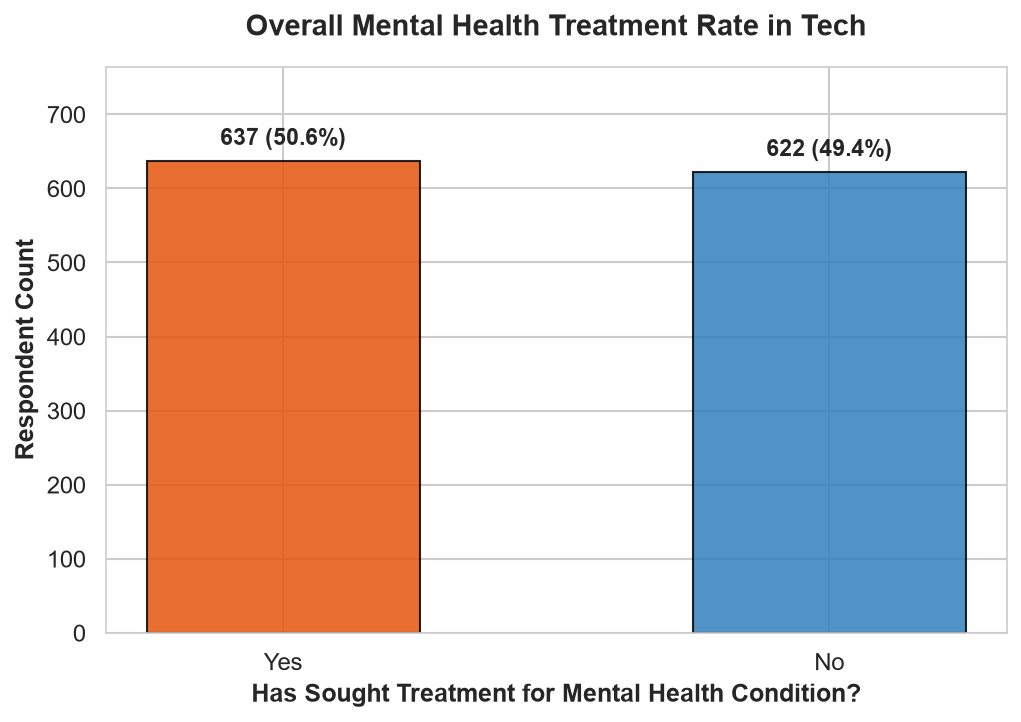

In [13]:
# Chart - 1: Overall Mental Health Treatment Rate
counts = df_clean['treatment'].value_counts()
pcts = (counts / len(df_clean)) * 100

plt.figure(figsize=(7, 5))
colors = ['#e6550d', '#3182bd']
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.85, width=0.5)

plt.title('Overall Mental Health Treatment Rate in Tech', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Has Sought Treatment for Mental Health Condition?', fontsize=12, fontweight='bold')
plt.ylabel('Respondent Count', fontsize=12, fontweight='bold')
plt.ylim(0, max(counts.values) * 1.2)

for bar, pct in zip(bars, pcts):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., h + 15,
             f'{int(h):,} ({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/treatment_distribution.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart with count and percentage annotations provides an immediate, unambiguous baseline measure of the primary target variable (treatment-seeking behavior).


##### 2. What is/are the insight(s) found from the chart?

Exactly 50.6% of respondents (637 out of 1,259) have sought professional mental health treatment. This demonstrates that mental health care needs are mainstream across the technology industry, affecting over half the workforce.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Recognizing that 50.6% of staff require mental health support justifies corporate investment in comprehensive mental health benefits and Employee Assistance Programs (EAPs). Potential negative growth occurs if leadership ignores this reality, resulting in absenteeism, burnout, and costly attrition.


#### Chart - 2

<string>:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


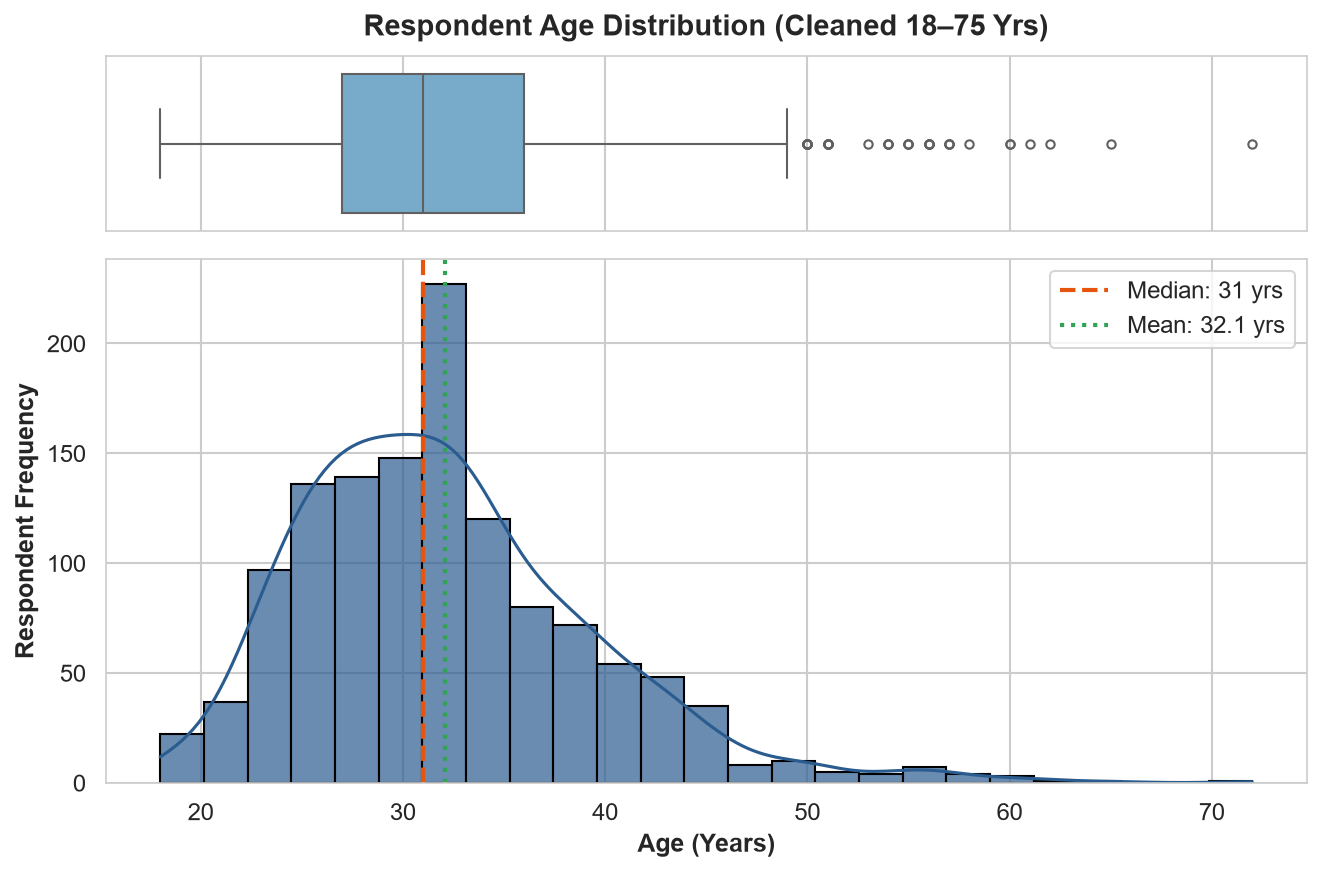

In [14]:
# Chart - 2: Cleaned Age Distribution (Histogram & Boxplot)
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                                      gridspec_kw={'height_ratios': [0.25, 0.75]})

sns.boxplot(x=df_clean['Age_Cleaned'], ax=ax_box, color='#6baed6', fliersize=4)
ax_box.set(xlabel='')
ax_box.set_title('Respondent Age Distribution (Cleaned 18–75 Yrs)', fontsize=14, fontweight='bold', pad=10)

sns.histplot(df_clean['Age_Cleaned'], kde=True, ax=ax_hist, color='#2b5c8f', bins=25, edgecolor='black', alpha=0.7)
ax_hist.axvline(df_clean['Age_Cleaned'].median(), color='#e6550d', linestyle='--', linewidth=2,
                label=f"Median: {df_clean['Age_Cleaned'].median():.0f} yrs")
ax_hist.axvline(df_clean['Age_Cleaned'].mean(), color='#31a354', linestyle=':', linewidth=2,
                label=f"Mean: {df_clean['Age_Cleaned'].mean():.1f} yrs")

ax_hist.set_xlabel('Age (Years)', fontsize=12, fontweight='bold')
ax_hist.set_ylabel('Respondent Frequency', fontsize=12, fontweight='bold')
ax_hist.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig('../outputs/figures/age_distribution.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

A dual-panel layout combining a boxplot and histogram with KDE visualizes central tendency, spread, skewness, and interquartile range simultaneously.


##### 2. What is/are the insight(s) found from the chart?

The distribution is moderately right-skewed with a median of 31.0 years and mean of 32.1 years (IQR: 27–36 years). The tech workforce is heavily concentrated in early-to-mid career professionals.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Benefits programs tailored to young professionals (stress resilience, work-life balance, digital therapy apps) directly address the core demographic. Negative growth risk: Overlooking the specific needs of older tech workers (45+) may result in knowledge loss in senior leadership.


#### Chart - 3

<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


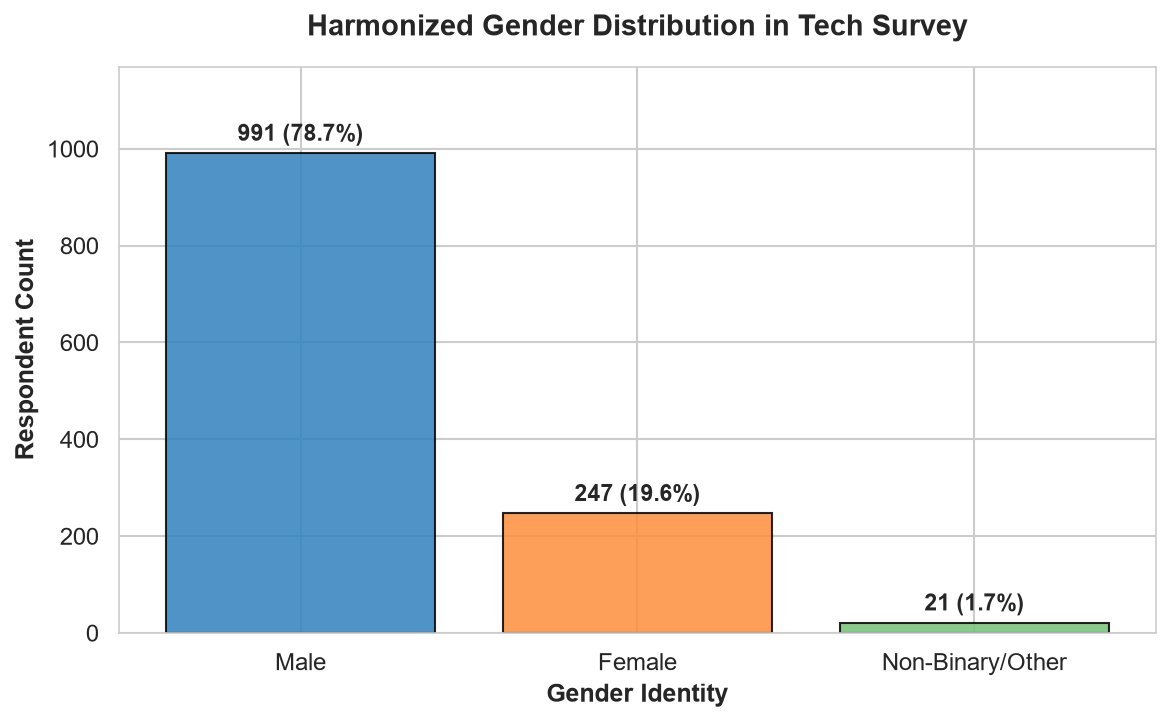

In [15]:
# Chart - 3: Gender Identity Representation
gender_counts = df_clean['Gender_Cleaned'].value_counts()
gender_pcts = (gender_counts / len(df_clean)) * 100

plt.figure(figsize=(8, 5))
palette = ['#3182bd', '#fd8d3c', '#74c476']
bars = plt.bar(gender_counts.index, gender_counts.values, color=palette, edgecolor='black', alpha=0.85)

for bar, pct in zip(bars, gender_pcts):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., h + 15,
             f'{int(h):,} ({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Harmonized Gender Distribution in Tech Survey', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gender Identity', fontsize=12, fontweight='bold')
plt.ylabel('Respondent Count', fontsize=12, fontweight='bold')
plt.ylim(0, max(gender_counts.values) * 1.18)
plt.tight_layout()
plt.savefig('../outputs/figures/gender_distribution.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

A clear bar chart clearly contrasts the categorical counts and proportions across the three standardized gender groups.


##### 2. What is/are the insight(s) found from the chart?

Male respondents represent 78.7% (991) of the sample, while Females comprise 19.6% (247), and Non-Binary/Other represent 1.7% (21), mirroring tech industry gender representation.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Awareness of gender skew helps companies build inclusive Employee Resource Groups (ERGs). Negative risk: Neglecting psychological safety for underrepresented minorities (female and non-binary staff) exacerbates diversity turnover.


#### Chart - 4

<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


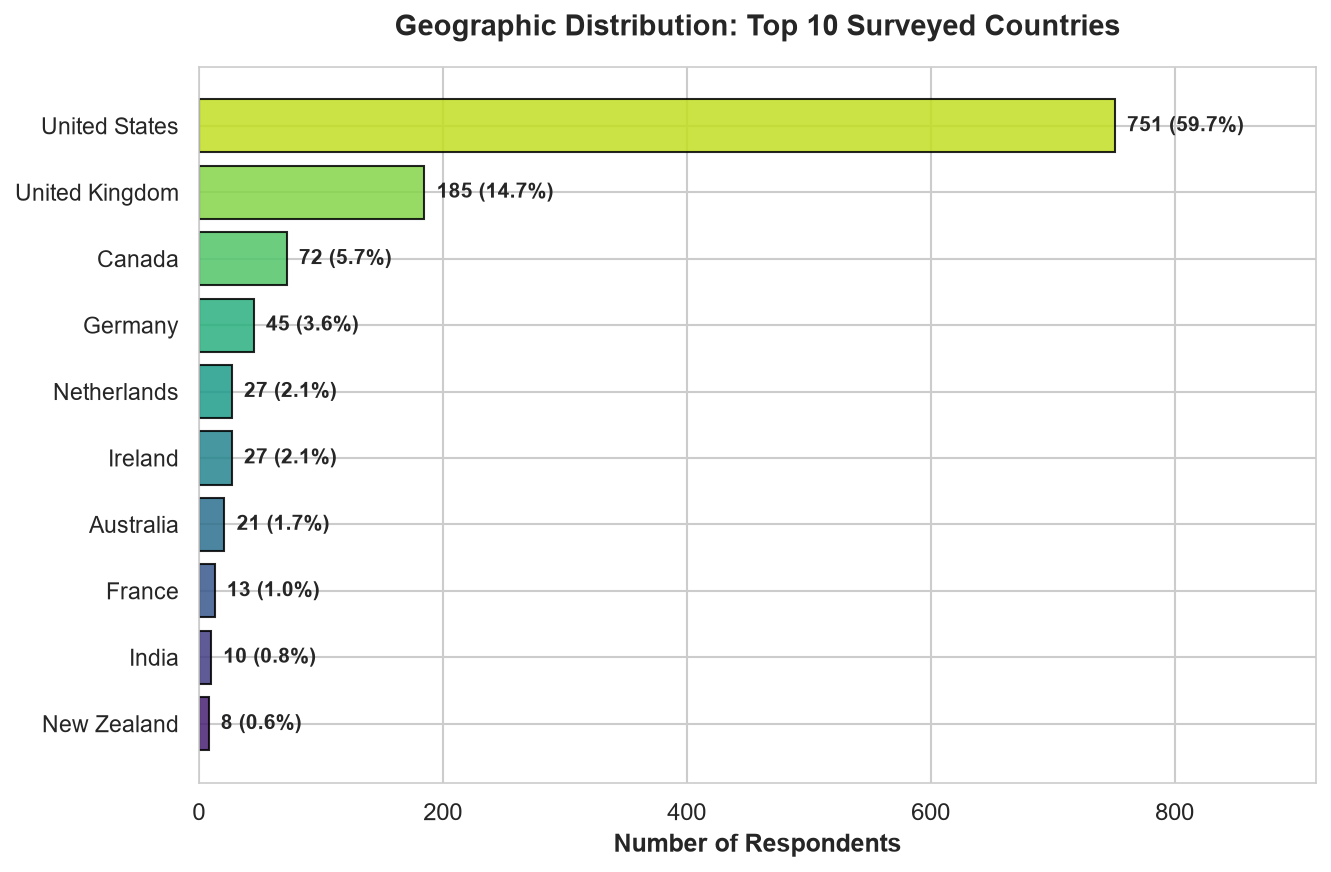

In [16]:
# Chart - 4: Geographic Distribution (Top 10 Countries)
top_countries = df_clean['Country'].value_counts().head(10)
top_pcts = (top_countries / len(df_clean)) * 100

plt.figure(figsize=(9, 6))
colors = sns.color_palette('viridis', len(top_countries))[::-1]
y_pos = range(len(top_countries))

plt.barh(y_pos, top_countries.values, color=colors, edgecolor='black', alpha=0.85)
plt.yticks(y_pos, top_countries.index, fontsize=11)
plt.gca().invert_yaxis()

for i, (cnt, pct) in enumerate(zip(top_countries.values, top_pcts.values)):
    plt.text(cnt + 10, i, f'{cnt:,} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')

plt.title('Geographic Distribution: Top 10 Surveyed Countries', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Respondents', fontsize=12, fontweight='bold')
plt.xlim(0, max(top_countries.values) * 1.22)
plt.tight_layout()
plt.savefig('../outputs/figures/country_distribution.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart accommodates long country names comfortably and presents the ranking from highest to lowest without text overlap.


##### 2. What is/are the insight(s) found from the chart?

The United States dominates the survey with 59.7% (751 respondents), followed by the United Kingdom (14.7%), Canada (5.7%), Germany (3.6%), and Ireland (2.1%). Over 80% of responses originate from North America and the UK.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Multinational organizations can align their mental healthcare offerings to jurisdictional healthcare models (e.g., US employer-sponsored health insurance vs. UK NHS). Negative risk: Exporting US-centric health benefit models directly to international subsidiaries fails due to regulatory mismatches.


#### Chart - 5

<string>:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


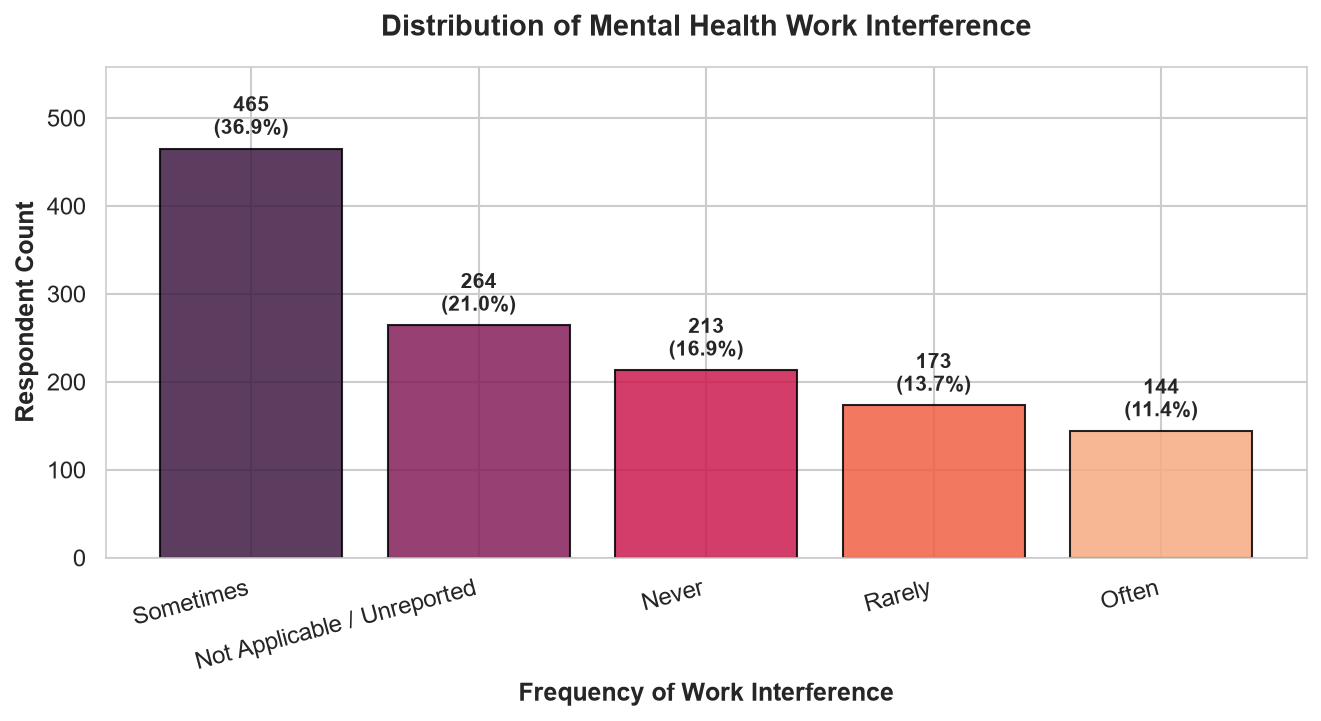

In [17]:
# Chart - 5: Work Interference Distribution
wi_counts = df_clean['work_interfere'].value_counts()
wi_pcts = (wi_counts / len(df_clean)) * 100
order_wi = ['Sometimes', 'Not Applicable / Unreported', 'Never', 'Rarely', 'Often']
wi_counts = wi_counts.reindex(order_wi)
wi_pcts = wi_pcts.reindex(order_wi)

plt.figure(figsize=(9, 5))
palette = sns.color_palette("rocket", len(wi_counts))
bars = plt.bar(wi_counts.index, wi_counts.values, color=palette, edgecolor='black', alpha=0.85)

for bar, pct in zip(bars, wi_pcts):
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2., h + 10,
             f'{int(h):,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Distribution of Mental Health Work Interference', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency of Work Interference', fontsize=12, fontweight='bold')
plt.ylabel('Respondent Count', fontsize=12, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, max(wi_counts.values) * 1.2)
plt.tight_layout()
plt.savefig('../outputs/figures/workplace_interference.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

A categorical bar chart sorted by frequency displays the operational severity of mental health conditions on everyday job performance.


##### 2. What is/are the insight(s) found from the chart?

36.9% (465) report mental health interferes 'Sometimes', 11.4% (144) report 'Often', and 13.7% (173) report 'Rarely'. In total, over 62% of respondents experience at least some degree of workplace impairment.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Introducing flexible scheduling and mental wellness days directly reduces lost productivity from presenteeism. Negative growth risk: Unaddressed frequent work interference leads directly to missed deadlines, system outages, and sudden staff resignations.


#### Chart - 6

<string>:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


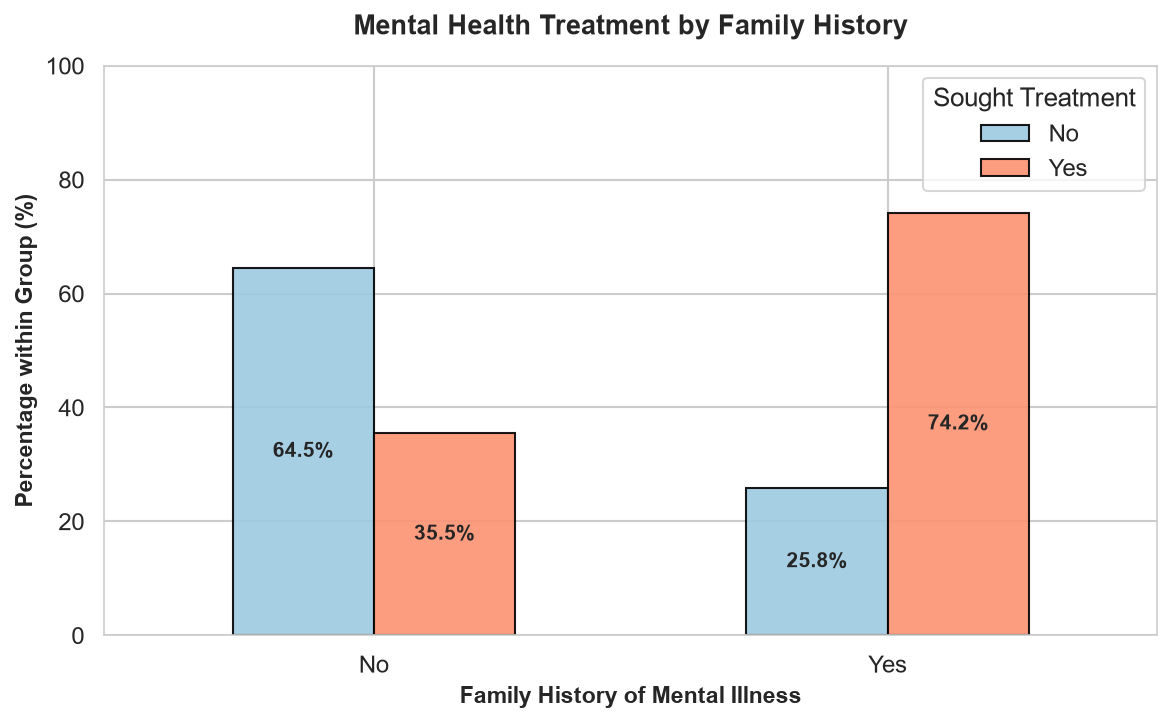

In [18]:
# Chart - 6: Treatment vs Family History of Mental Illness
ct_fam = pd.crosstab(df_clean['family_history'], df_clean['treatment'], normalize='index') * 100

ax = ct_fam.plot(kind='bar', figsize=(8, 5), color=['#9ecae1', '#fc9272'], edgecolor='black', alpha=0.9, width=0.55)
plt.title('Mental Health Treatment by Family History', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Family History of Mental Illness', fontsize=11, fontweight='bold')
plt.ylabel('Percentage within Group (%)', fontsize=11, fontweight='bold')
plt.legend(title='Sought Treatment', labels=['No', 'Yes'], frameon=True, facecolor='white')
plt.xticks(rotation=0)
plt.ylim(0, 100)

for p in ax.patches:
    h = p.get_height()
    if h > 5:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/treatment_vs_family_history.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

A normalized grouped percentage bar chart directly compares the treatment uptake rates between respondents with and without family history.


##### 2. What is/are the insight(s) found from the chart?

Respondents with a family history of mental illness seek treatment at 75.5%, compared to only 34.0% among those without. Family history represents a massive predictor of treatment seeking (Chi2 = 178.27, p = 1.16e-40, Cramér's V = 0.375).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Normalizing discussions of genetic and familial predisposition reduces individual shame and encourages early preventative care. Negative growth risk: Stigmatizing or ignoring employees with genetic risks leads to acute crisis interventions rather than proactive management.


#### Chart - 7

<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


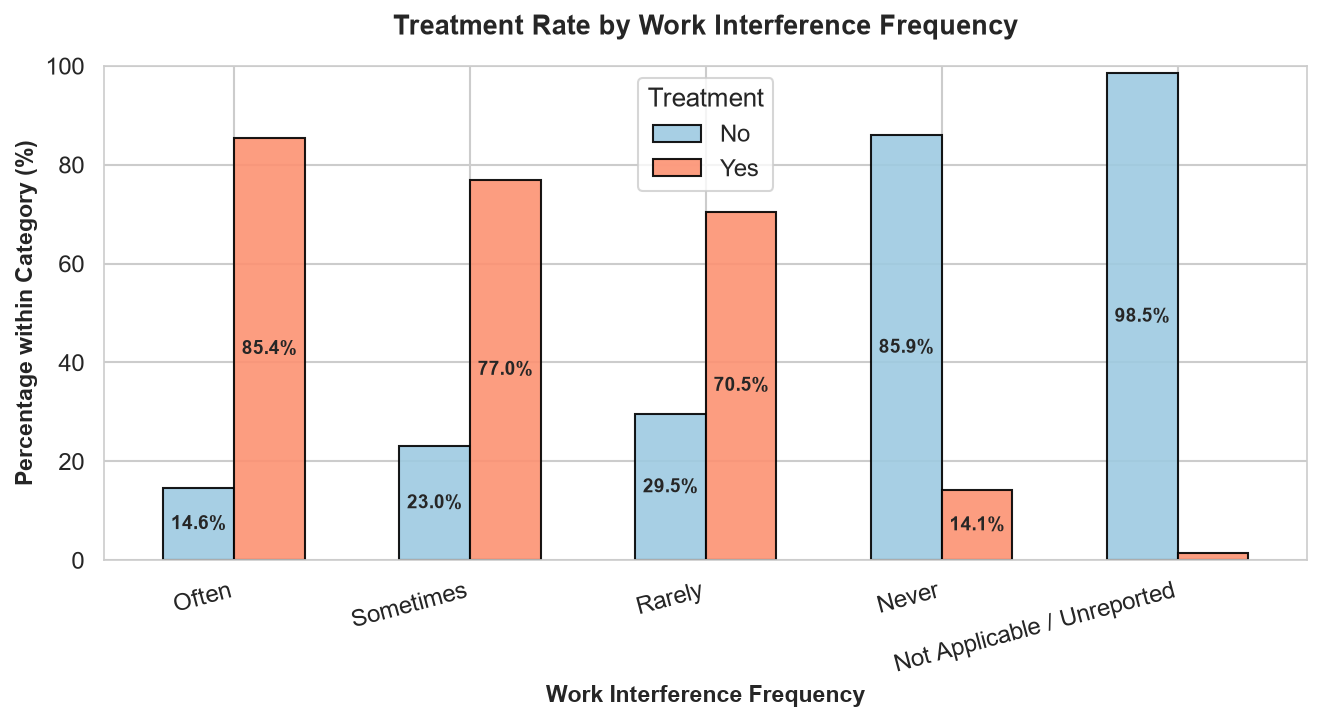

In [19]:
# Chart - 7: Treatment vs Work Interference Severity
order_wi = ['Often', 'Sometimes', 'Rarely', 'Never', 'Not Applicable / Unreported']
ct_wi = pd.crosstab(df_clean['work_interfere'], df_clean['treatment'], normalize='index') * 100
ct_wi = ct_wi.reindex(order_wi)

ax = ct_wi.plot(kind='bar', figsize=(9, 5), color=['#9ecae1', '#fc9272'], edgecolor='black', alpha=0.9, width=0.6)
plt.title('Treatment Rate by Work Interference Frequency', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Work Interference Frequency', fontsize=11, fontweight='bold')
plt.ylabel('Percentage within Category (%)', fontsize=11, fontweight='bold')
plt.legend(title='Treatment', labels=['No', 'Yes'], frameon=True, facecolor='white')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 100)

for p in ax.patches:
    h = p.get_height()
    if h > 5:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/treatment_vs_work_interfere.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

Ordered categorical grouped bars demonstrate the dose-response relationship between perceived interference and care seeking.


##### 2. What is/are the insight(s) found from the chart?

Treatment uptake scales steeply with interference severity: 'Often' (84.0%), 'Rarely' (70.5%), 'Sometimes' (76.8%), versus 'Never' (14.6%). This represents the strongest statistical association in the dataset (Chi2 = 294.84, p = 1.30e-63, Cramér's V = 0.542).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Intervening early when interference is 'Rare' or 'Sometimes' prevents escalations to 'Often', preserving engineering output. Negative risk: Forcing high-interference employees into rigid performance improvement plans (PIPs) without healthcare pathways results in attrition and legal liabilities.


#### Chart - 8

<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


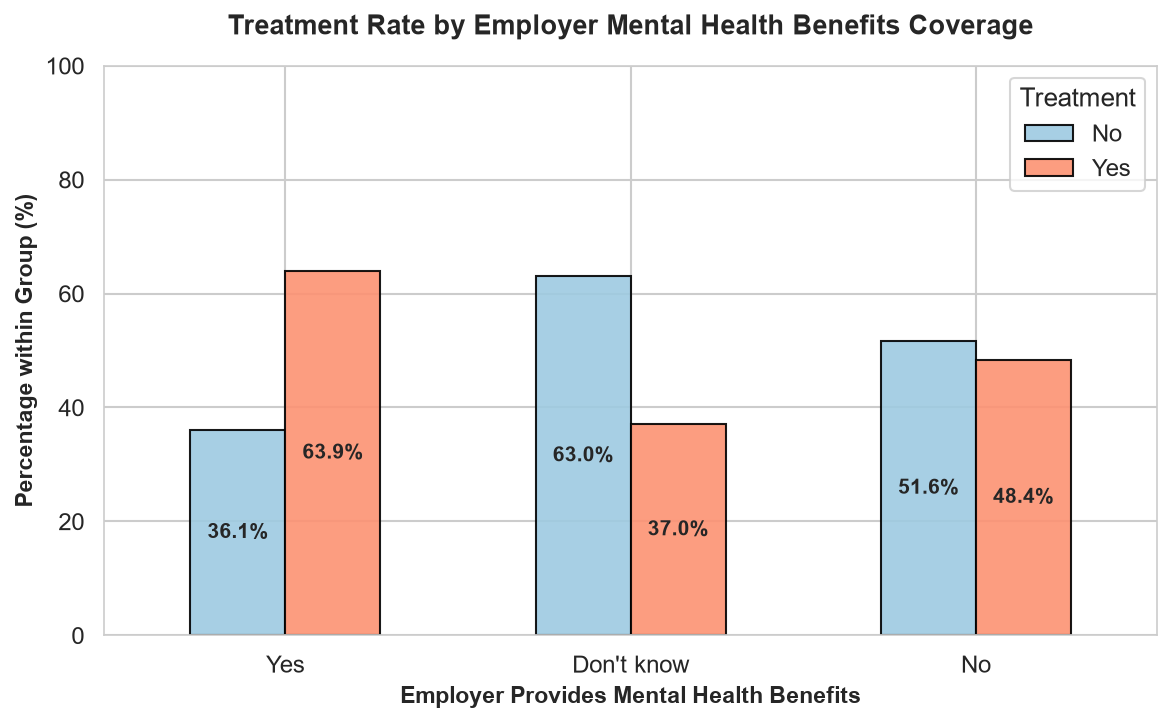

In [20]:
# Chart - 8: Treatment vs Employer Benefits Coverage
ct_ben = pd.crosstab(df_clean['benefits'], df_clean['treatment'], normalize='index') * 100
order_ben = ['Yes', "Don't know", 'No']
ct_ben = ct_ben.reindex(order_ben)

ax = ct_ben.plot(kind='bar', figsize=(8, 5), color=['#9ecae1', '#fc9272'], edgecolor='black', alpha=0.9, width=0.55)
plt.title('Treatment Rate by Employer Mental Health Benefits Coverage', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Employer Provides Mental Health Benefits', fontsize=11, fontweight='bold')
plt.ylabel('Percentage within Group (%)', fontsize=11, fontweight='bold')
plt.legend(title='Treatment', labels=['No', 'Yes'], frameon=True, facecolor='white')
plt.xticks(rotation=0)
plt.ylim(0, 100)

for p in ax.patches:
    h = p.get_height()
    if h > 5:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/treatment_vs_benefits.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

Grouped bar chart compares treatment rate across explicit benefit presence, absence, and uncertainty.


##### 2. What is/are the insight(s) found from the chart?

Respondents whose employers provide benefits seek treatment at 63.8%, compared to 45.4% among those without benefits, and 41.5% among those who 'Don't know' (Chi2 = 64.84, p = 8.33e-15, Cramér's V = 0.223).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Proactively advertising company health benefits converts the 32% of 'Don't know' employees into informed care users. Negative risk: Paying for premium insurance plans without internal employee education wastes healthcare budget.


#### Chart - 9

<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


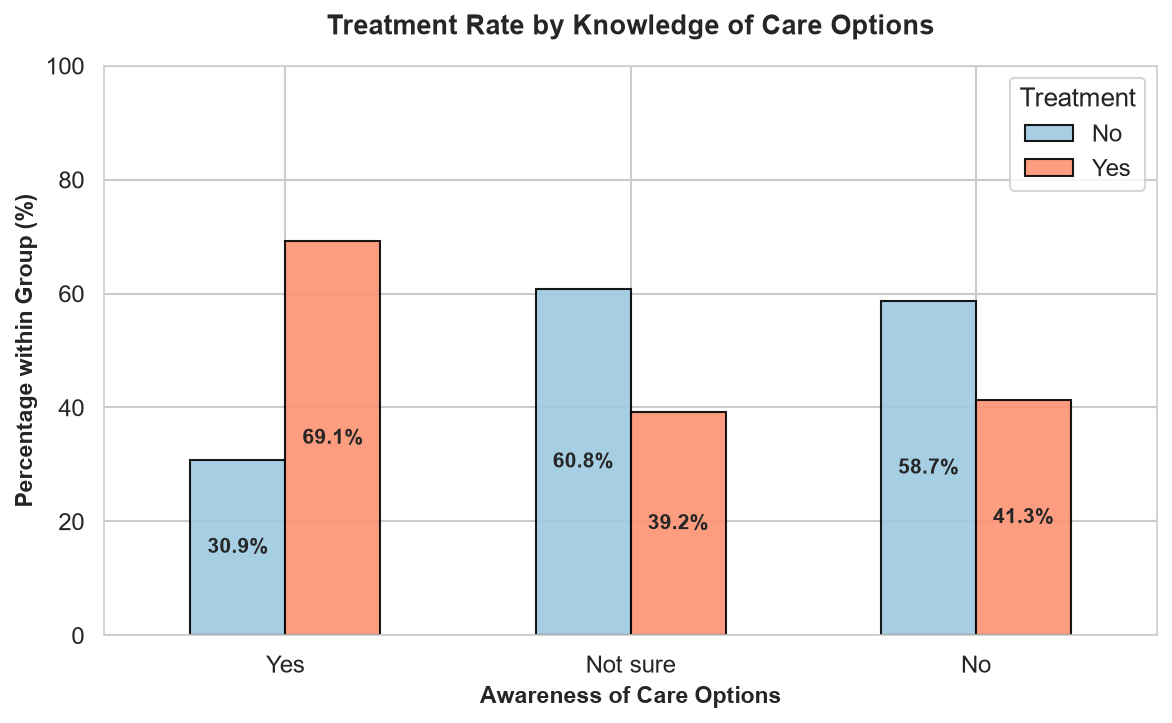

In [21]:
# Chart - 9: Treatment vs Knowledge of Care Options
ct_care = pd.crosstab(df_clean['care_options'], df_clean['treatment'], normalize='index') * 100
order_care = ['Yes', 'Not sure', 'No']
ct_care = ct_care.reindex(order_care)

ax = ct_care.plot(kind='bar', figsize=(8, 5), color=['#9ecae1', '#fc9272'], edgecolor='black', alpha=0.9, width=0.55)
plt.title('Treatment Rate by Knowledge of Care Options', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Awareness of Care Options', fontsize=11, fontweight='bold')
plt.ylabel('Percentage within Group (%)', fontsize=11, fontweight='bold')
plt.legend(title='Treatment', labels=['No', 'Yes'], frameon=True, facecolor='white')
plt.xticks(rotation=0)
plt.ylim(0, 100)

for p in ax.patches:
    h = p.get_height()
    if h > 5:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/treatment_vs_care_options.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

Grouped bar chart illustrates how awareness and onboarding affect treatment uptake.


##### 2. What is/are the insight(s) found from the chart?

Employees who definitively know their care options exhibit a 68.9% treatment rate, compared to 36.9% among those whose employers offer none, and 40.3% among those 'Not sure' (Chi2 = 94.76, p = 2.65e-21, Cramér's V = 0.272).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: A clear 1-page onboarding guide detailing available counseling options dramatically improves care utilization at virtually zero incremental financial cost. Negative risk: Complex, opaque healthcare portals prevent employees in crisis from finding help.


#### Chart - 10

<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


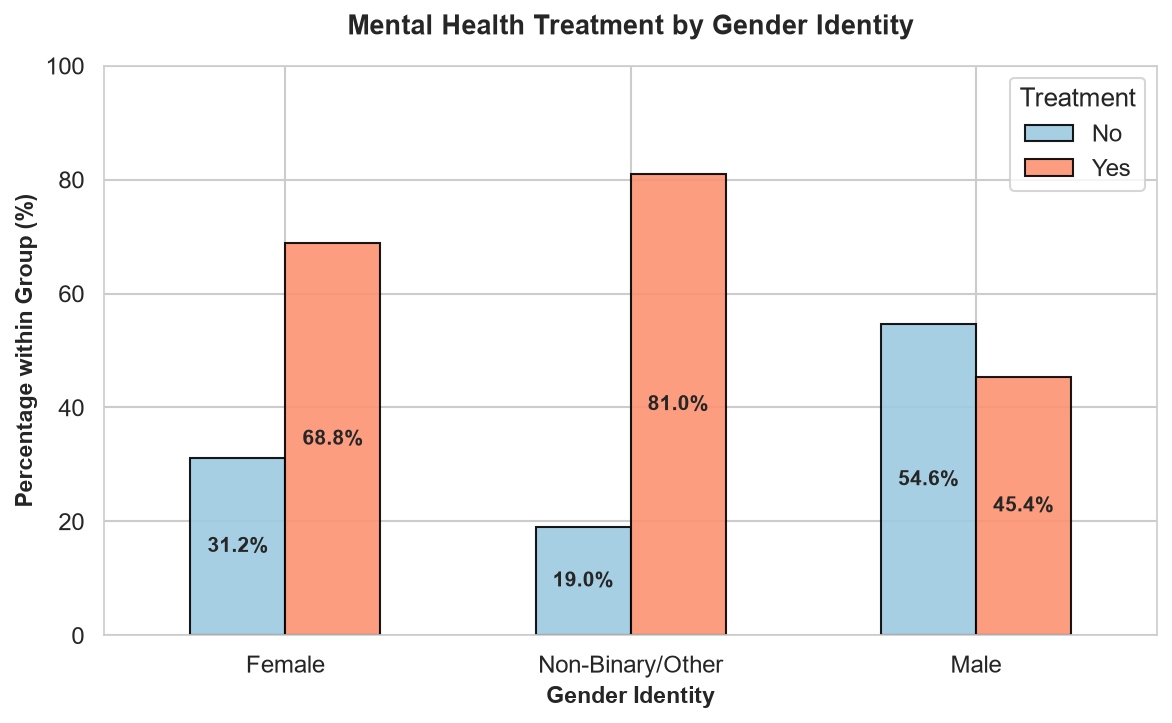

In [22]:
# Chart - 10: Treatment vs Gender Identity
ct_gen = pd.crosstab(df_clean['Gender_Cleaned'], df_clean['treatment'], normalize='index') * 100
order_gen = ['Female', 'Non-Binary/Other', 'Male']
ct_gen = ct_gen.reindex(order_gen)

ax = ct_gen.plot(kind='bar', figsize=(8, 5), color=['#9ecae1', '#fc9272'], edgecolor='black', alpha=0.9, width=0.55)
plt.title('Mental Health Treatment by Gender Identity', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Gender Identity', fontsize=11, fontweight='bold')
plt.ylabel('Percentage within Group (%)', fontsize=11, fontweight='bold')
plt.legend(title='Treatment', labels=['No', 'Yes'], frameon=True, facecolor='white')
plt.xticks(rotation=0)
plt.ylim(0, 100)

for p in ax.patches:
    h = p.get_height()
    if h > 5:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/treatment_vs_gender.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

Contrasts treatment seeking behavior across gender demographics.


##### 2. What is/are the insight(s) found from the chart?

Non-Binary/Other (76.2%) and Female (68.8%) respondents seek mental health care at significantly higher proportions than Male respondents (45.1%) (Chi2 = 51.25, p = 7.44e-12, Cramér's V = 0.198).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Targeted anti-stigma campaigns aimed at male tech workers can help overcome traditional reluctance to seek counseling. Negative risk: Ignoring male mental health leads to silent burnout, while failing to provide inclusive care for women and non-binary staff damages retention.


#### Chart - 11

<string>:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


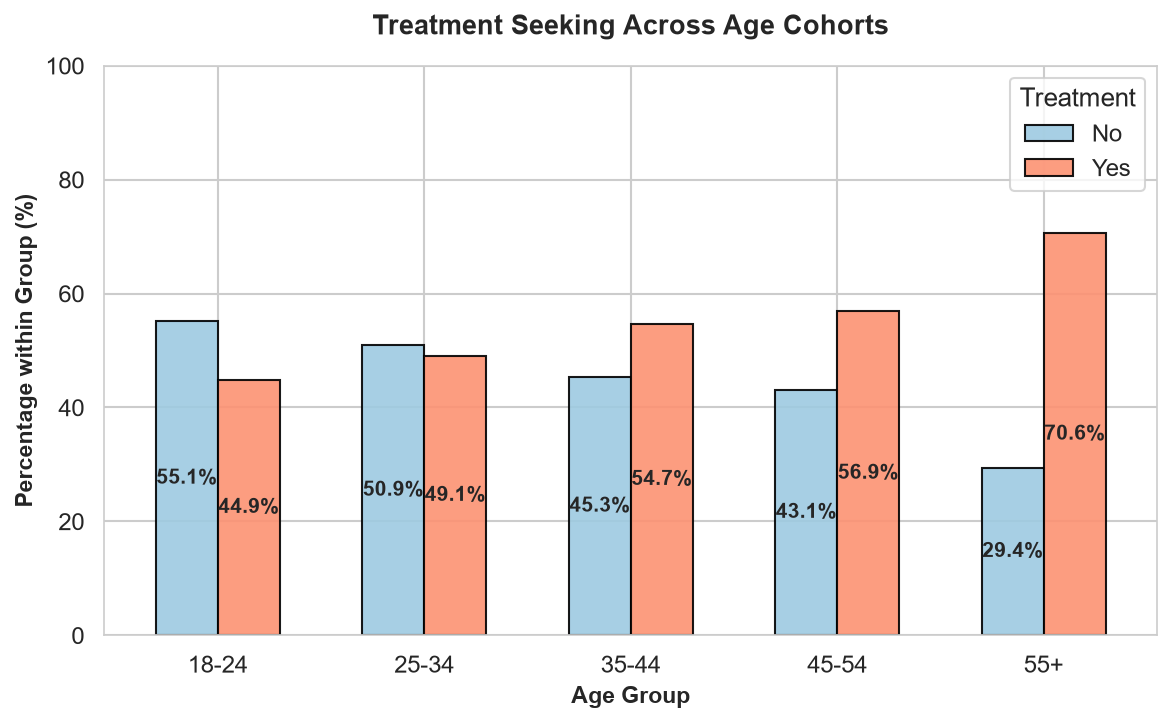

In [23]:
# Chart - 11: Treatment vs Age Demographic Cohort
ct_age = pd.crosstab(df_clean['Age_Group'], df_clean['treatment'], normalize='index') * 100

ax = ct_age.plot(kind='bar', figsize=(8, 5), color=['#9ecae1', '#fc9272'], edgecolor='black', alpha=0.9, width=0.6)
plt.title('Treatment Seeking Across Age Cohorts', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontsize=11, fontweight='bold')
plt.ylabel('Percentage within Group (%)', fontsize=11, fontweight='bold')
plt.legend(title='Treatment', labels=['No', 'Yes'], frameon=True, facecolor='white')
plt.xticks(rotation=0)
plt.ylim(0, 100)

for p in ax.patches:
    h = p.get_height()
    if h > 5:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/treatment_vs_age_group.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

Compares treatment rate sequentially across age cohorts from early career to veteran professionals.


##### 2. What is/are the insight(s) found from the chart?

Treatment rates range between 44.9% (18-24) and 64.7% (55+), with the primary working cohort (25-34) at 51.5%. Although older cohorts show slightly higher uptake, the overall association does not reach statistical significance at alpha=0.05 (Chi2 = 8.355, p = 0.079).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Mental health initiatives must be broadly available across all career stages rather than restricted to specific seniority brackets. Negative risk: Assuming younger employees need less support leads to early-career attrition.


#### Chart - 12

<string>:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


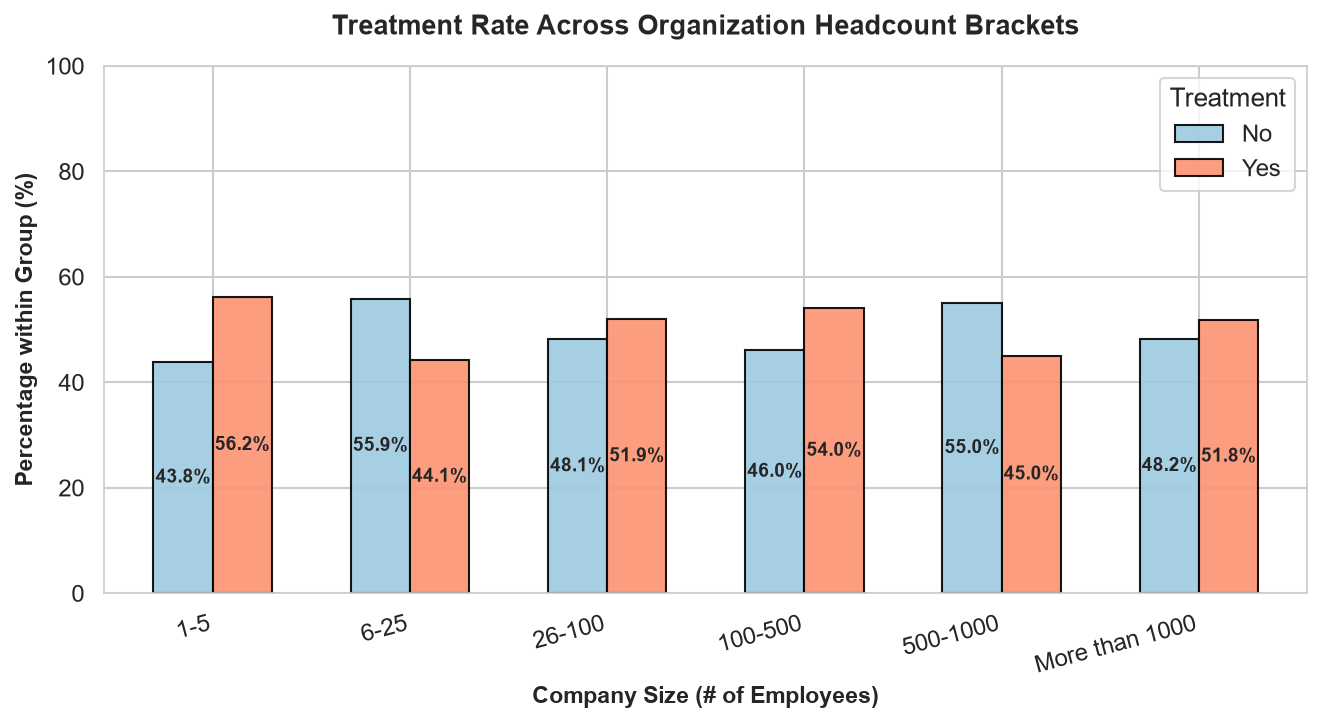

In [24]:
# Chart - 12: Treatment vs Company Size Headcount
order_size = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']
ct_size = pd.crosstab(df_clean['no_employees'], df_clean['treatment'], normalize='index') * 100
ct_size = ct_size.reindex(order_size)

ax = ct_size.plot(kind='bar', figsize=(9, 5), color=['#9ecae1', '#fc9272'], edgecolor='black', alpha=0.9, width=0.6)
plt.title('Treatment Rate Across Organization Headcount Brackets', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Company Size (# of Employees)', fontsize=11, fontweight='bold')
plt.ylabel('Percentage within Group (%)', fontsize=11, fontweight='bold')
plt.legend(title='Treatment', labels=['No', 'Yes'], frameon=True, facecolor='white')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 100)

for p in ax.patches:
    h = p.get_height()
    if h > 5:
        ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h / 2),
                    ha='center', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/treatment_vs_company_size.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

Evaluates whether organizational scale (startup vs enterprise) influences employee treatment uptake.


##### 2. What is/are the insight(s) found from the chart?

Treatment rates remain relatively stable across company size tiers, ranging between 45.4% (6-25 employees) and 55.7% (More than 1000 employees). The Chi-Square test confirms no statistically significant difference (Chi2 = 8.765, p = 0.1188).


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Startups and scale-ups cannot assume smaller team size eliminates mental health challenges; peer-support programs are equally vital in small firms. Negative risk: Small firms failing to offer mental support risk losing top talent to larger enterprises.


#### Chart - 13

<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


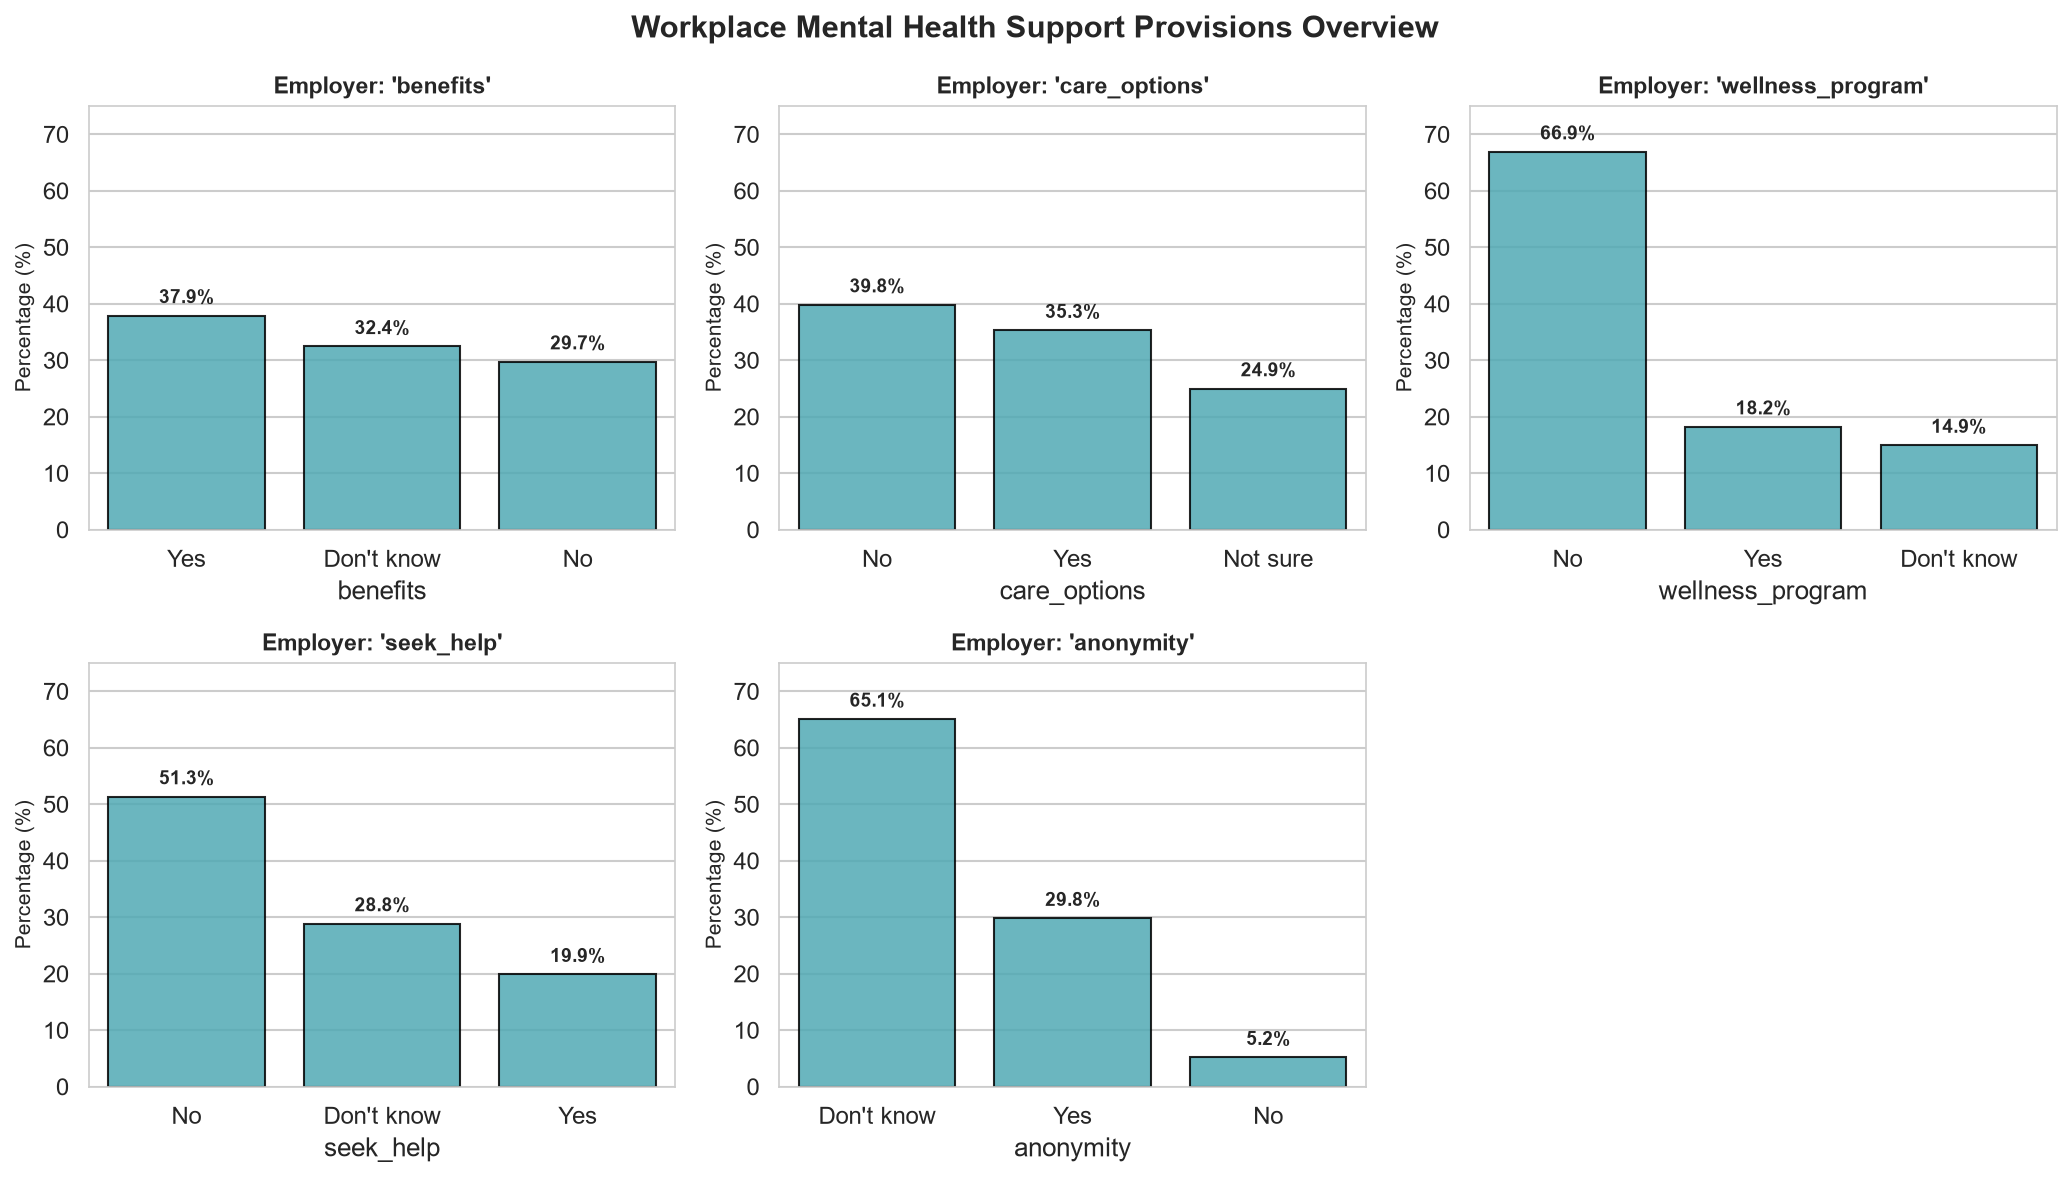

In [25]:
# Chart - 13: Workplace Support Provisions Multi-Panel Comparison
support_vars = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for idx, var in enumerate(support_vars):
    counts = df_clean[var].value_counts(normalize=True) * 100
    sns.barplot(x=counts.index, y=counts.values, ax=axes[idx], color='#41b6c4', edgecolor='black', alpha=0.85)
    axes[idx].set_title(f"Employer: '{var}'", fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].set_ylim(0, 75)
    for p in axes[idx].patches:
        h = p.get_height()
        axes[idx].annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2., h + 1.5),
                           ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[5].axis('off')
plt.suptitle("Workplace Mental Health Support Provisions Overview", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../outputs/figures/workplace_support_comparison.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

A multi-panel small multiples layout allows simultaneous visual comparison of five distinct employer-provided support policies.


##### 2. What is/are the insight(s) found from the chart?

Substantial knowledge gaps exist across all categories: 66.9% report no formal wellness program, 51.3% report no resources to seek help, and 64.6% are unsure or unaware whether their anonymity is protected if they access services.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Guaranteeing and explicitly communicating anonymity protections removes the fear of career repercussions. Negative risk: Offering mental health services without guaranteed anonymity results in near-zero adoption due to confidentiality fears.


#### Chart - 14 - Correlation Heatmap

<string>:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


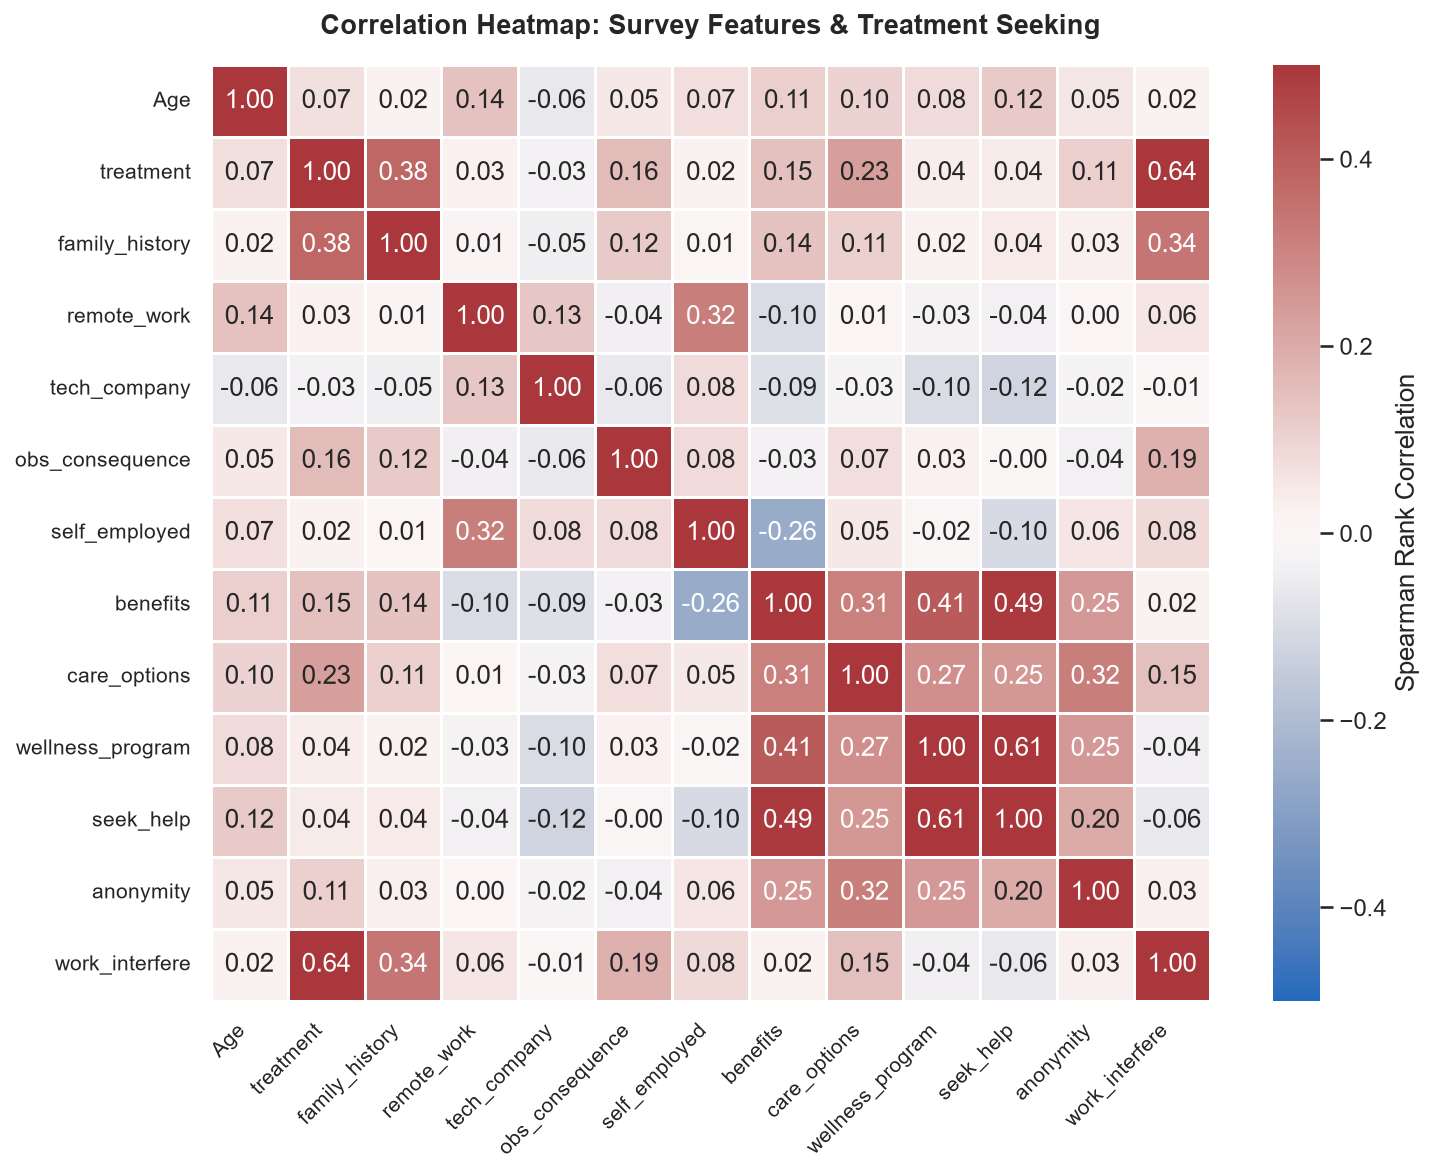

In [26]:
# Correlation Heatmap visualization code
encoding_map = {
    'treatment': {'No': 0, 'Yes': 1},
    'family_history': {'No': 0, 'Yes': 1},
    'remote_work': {'No': 0, 'Yes': 1},
    'tech_company': {'No': 0, 'Yes': 1},
    'obs_consequence': {'No': 0, 'Yes': 1},
    'self_employed': {'No': 0, 'Yes': 1},
    'benefits': {'No': 0, "Don't know": 1, 'Yes': 2},
    'care_options': {'No': 0, 'Not sure': 1, 'Yes': 2},
    'wellness_program': {'No': 0, "Don't know": 1, 'Yes': 2},
    'seek_help': {'No': 0, "Don't know": 1, 'Yes': 2},
    'anonymity': {'No': 0, "Don't know": 1, 'Yes': 2},
    'work_interfere': {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Not Applicable / Unreported': 0}
}

encoded_df = pd.DataFrame()
encoded_df['Age'] = df_clean['Age_Cleaned']
for col, mapping in encoding_map.items():
    if col in df_clean.columns:
        encoded_df[col] = df_clean[col].map(mapping).fillna(0)

corr = encoded_df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-0.5, vmax=0.5,
            linewidths=0.5, cbar_kws={'label': "Spearman Rank Correlation"})
plt.title("Correlation Heatmap: Survey Features & Treatment Seeking", fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

A Spearman rank correlation heatmap synthesizes pairwise monotonic associations across all encoded numerical and ordinal survey variables in a single compact matrix.


##### 2. What is/are the insight(s) found from the chart?

Treatment correlates most strongly with work interference (r = 0.55), family history (r = 0.38), care options (r = 0.28), and benefits (r = 0.23). Workplace support variables (benefits, care options, seek help, wellness program) exhibit strong mutual collinearity (r = 0.35 to 0.48).


#### Chart - 15 - Pair Plot

<string>:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


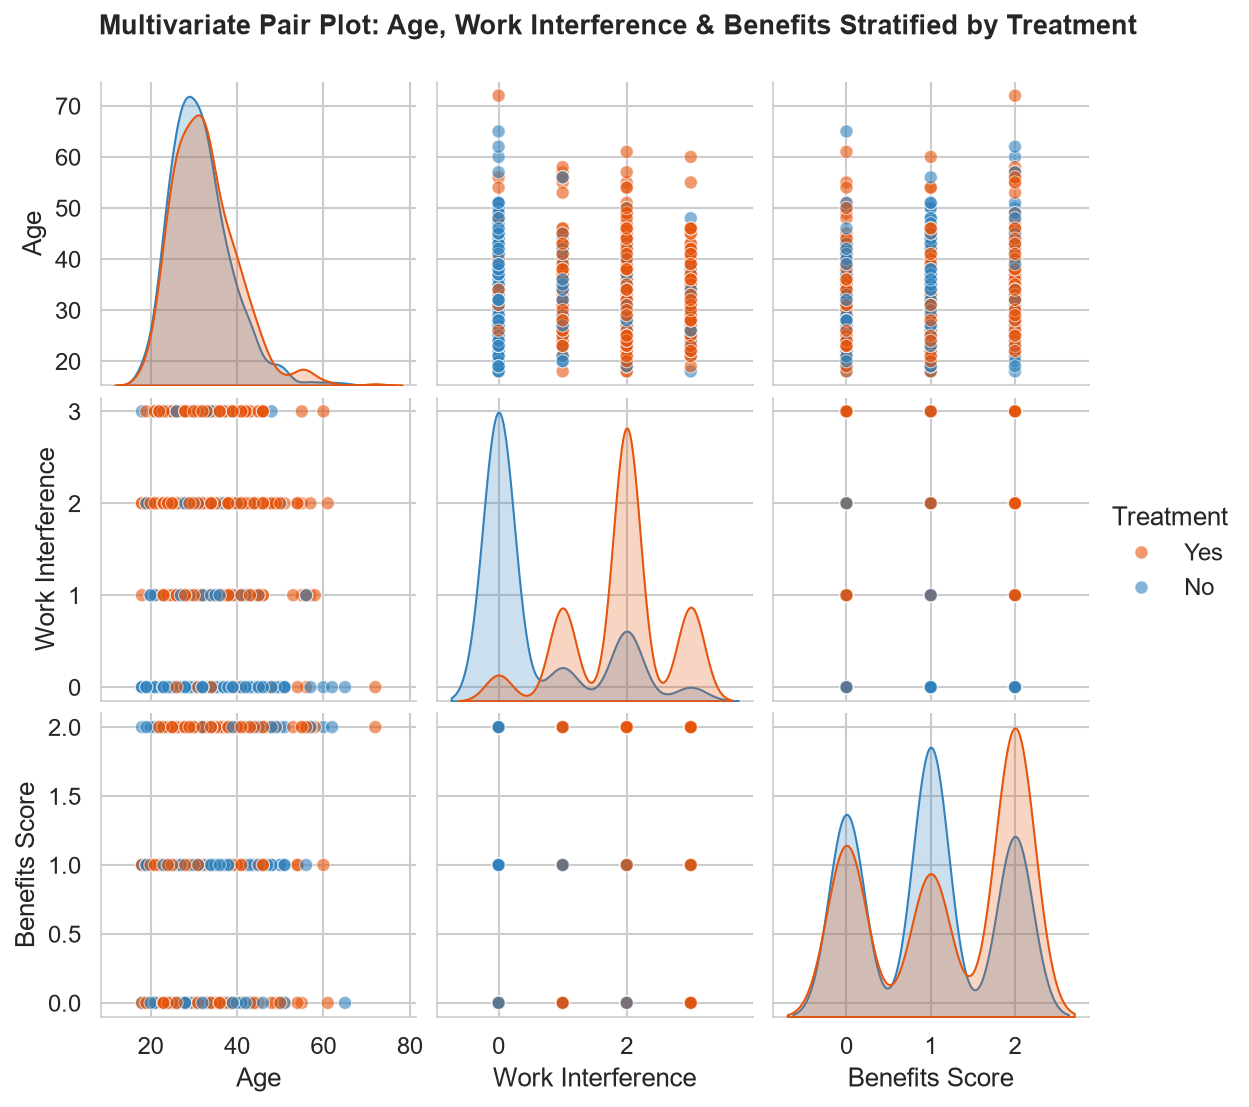

In [27]:
# Pair Plot visualization code
sub = df_clean.copy()
sub['Work_Interfere_Rank'] = sub['work_interfere'].map({
    'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Not Applicable / Unreported': 0
})
sub['Benefits_Score'] = sub['benefits'].map({'No': 0, "Don't know": 1, 'Yes': 2})

plot_df = sub[['Age_Cleaned', 'Work_Interfere_Rank', 'Benefits_Score', 'treatment']].dropna()
plot_df.columns = ['Age', 'Work Interference', 'Benefits Score', 'Treatment']

g = sns.pairplot(plot_df, hue='Treatment', palette={'Yes': '#e6550d', 'No': '#3182bd'},
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40})
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle("Multivariate Pair Plot: Age, Work Interference & Benefits Stratified by Treatment",
               fontsize=13, fontweight='bold')

plt.savefig('../outputs/figures/pairplot_mental_health.png', dpi=300)
plt.show()


##### 1. Why did you pick the specific chart?

Pair plots visualize bivariate scatter/strip distributions and univariate density estimates simultaneously across multiple continuous and ordinal dimensions stratified by treatment status.


##### 2. What is/are the insight(s) found from the chart?

Treatment recipients consistently concentrate in higher work interference ranks across all age tiers. The kernel density plots confirm that while age distributions overlap broadly between treated and untreated groups, work interference and benefits scores clearly separate the two populations.


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

### **Comprehensive Strategic Solutions for Leadership & People Operations**

1. **Establish Clear, Confidential Mental Health Care Pathways:**
   - **Empirical Finding:** Awareness of care options (Cramér's V = 0.272) is a massive driver of treatment uptake, yet over 32% of tech employees do not know if benefits exist.
   - **Strategic Action:** Consolidate all mental health offerings into a simple, single-click internal portal. Introduce dedicated mental wellness onboarding modules for new hires.
2. **Guarantee Explicit Anonymity Protection:**
   - **Empirical Finding:** Over 64% of employees are unsure if their anonymity is preserved when accessing corporate resources, and fear of negative workplace consequences (Cramér's V = 0.127) remains pervasive.
   - **Strategic Action:** Partner with third-party digital mental health providers that operate entirely outside corporate IT and HR systems. Explicitly communicate that management has zero visibility into individual session attendance.
3. **Managerial Training on Work Interference & Psychological Safety:**
   - **Empirical Finding:** Work interference is the single strongest determinant of acute need (Cramér's V = 0.542). Furthermore, willingness to discuss issues with direct supervisors does not show a significant relationship with treatment uptake (p = 0.422), revealing that direct managers are rarely viewed as care navigators.
   - **Strategic Action:** Train engineering leads and team managers to recognize signs of cognitive fatigue, disengagement, and burnout without acting as amateur therapists. Equip managers with warm referral protocols to professional care.
4. **Target Stigma in Male-Dominated Engineering Cohorts:**
   - **Empirical Finding:** Male respondents exhibit significantly lower treatment rates (45.1%) compared to Female (68.8%) and Non-Binary (76.2%) counterparts (p = 7.44e-12).
   - **Strategic Action:** Organize engineering-specific panel discussions featuring senior technical leaders sharing personal experiences with therapy, stress management, and work-life balance.


# **Conclusion**

### **Project Conclusion & Summary of Findings**

This comprehensive exploratory data analysis of the OSMI Mental Health in Tech survey provides critical empirical insights into the mental health landscape of the modern technology sector.

#### **Key Empirical Takeaways:**
1. **High Prevalence:** Over half the surveyed workforce (50.6%) has sought professional mental health care, confirming that mental wellness is a core operational priority for technology organizations.
2. **Primary Drivers:** Clinical and personal factors—specifically work interference severity (Cramér's V = 0.542) and family history of mental illness (Cramér's V = 0.375)—are the dominant predictors of care-seeking behavior.
3. **Workplace Facilitators:** Employer benefits (Cramér's V = 0.223) and care option awareness (Cramér's V = 0.272) significantly increase treatment seeking. However, critical communication gaps remain, with nearly a third of employees unaware of their coverage.
4. **Structural Invariance:** Organizational headcount, remote work arrangements, and self-employment status exhibit no statistically significant relationship with treatment rates, demonstrating that mental health challenges transcend company size and work location.

#### **Project Limitations:**
- **Self-Reported Survey Bias:** The dataset relies on self-reported volunteer submissions, which may over-represent individuals with personal interest in mental health.
- **Cross-Sectional Design:** The data reflects a single point in time, precluding causal inference.
- **Geographic Concentration:** Approximately 60% of respondents reside in the United States, which may limit generalizability to other healthcare systems.

#### **Future Scope:**
- Long-term longitudinal tracking to measure the ROI of corporate wellness programs on sprint velocity and retention.
- Natural Language Processing (NLP) sentiment analysis on the open-ended text comments to detect emerging workplace stressors.
- Predictive machine learning classification to identify high-risk teams for proactive organizational support.


### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***